In [55]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [57]:
data = pd.read_csv("Downloads/recruitment_data.csv")
data

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26,1,2,0,3,26.783828,48,78,91,1,1
1,39,1,4,12,3,25.862694,35,68,80,2,1
2,48,0,2,3,2,9.920805,20,67,13,2,0
3,34,1,2,5,2,6.407751,36,27,70,3,0
4,30,0,1,6,1,43.105343,23,52,85,2,0
...,...,...,...,...,...,...,...,...,...,...,...
1495,48,0,2,3,4,9.183783,66,3,80,3,1
1496,27,1,2,10,3,14.847731,43,97,7,2,0
1497,24,1,1,1,2,4.289911,31,91,58,1,1
1498,48,0,2,4,4,36.299263,9,37,44,2,1


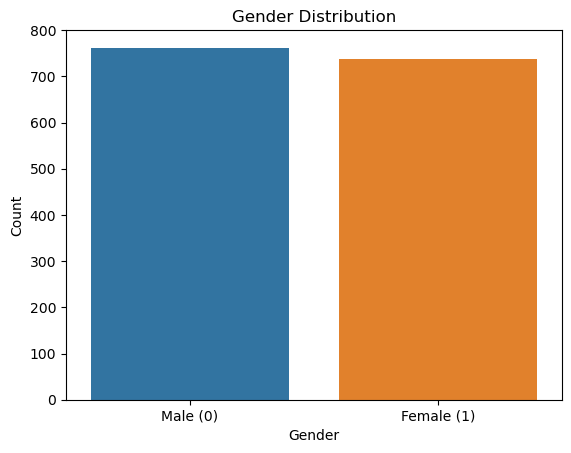

In [59]:
sns.countplot(x="Gender", data=data)

plt.xticks([0,1], ["Male (0)", "Female (1)"])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [71]:
data.groupby("Gender")["HiringDecision"].mean()

Gender
0    0.311024
1    0.308943
Name: HiringDecision, dtype: float64

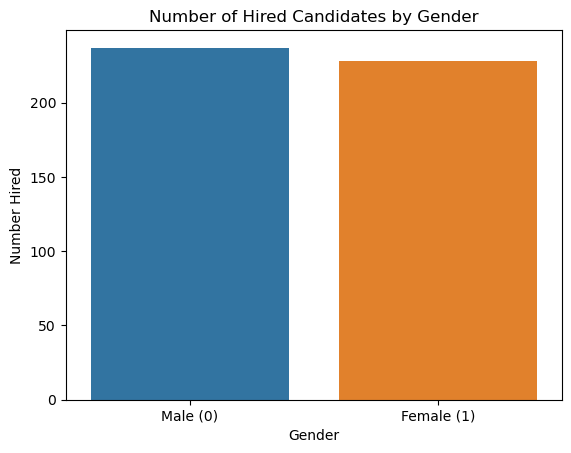

In [73]:
hired = data[data["HiringDecision"] == 1]

sns.countplot(x="Gender", data=hired)

plt.xticks([0,1], ["Male (0)", "Female (1)"])
plt.title("Number of Hired Candidates by Gender")
plt.xlabel("Gender")
plt.ylabel("Number Hired")
plt.show()

In [9]:
X = data.drop("HiringDecision", axis=1)
y = data["HiringDecision"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [17]:
y_pred_log = log_model.predict(X_test)

In [19]:
print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

===== Logistic Regression =====
Accuracy: 0.8666666666666667
[[198  17]
 [ 23  62]]
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       215
           1       0.78      0.73      0.76        85

    accuracy                           0.87       300
   macro avg       0.84      0.83      0.83       300
weighted avg       0.86      0.87      0.87       300



In [21]:
svm_model = SVC(kernel='linear') 
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [23]:
y_pred_svm = svm_model.predict(X_test)

In [25]:
print("===== SVM =====")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

===== SVM =====
Accuracy: 0.9
[[204  11]
 [ 19  66]]
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       215
           1       0.86      0.78      0.81        85

    accuracy                           0.90       300
   macro avg       0.89      0.86      0.87       300
weighted avg       0.90      0.90      0.90       300



In [27]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [29]:
X_test_df["Gender"] = data.loc[X_test_df.index, "Gender"]
X_test_df["Actual"] = y_test.values
X_test_df["Predicted"] = y_pred_log

In [31]:
print("Selection Rate by Gender:")
print(X_test_df.groupby("Gender")["Predicted"].mean())

Selection Rate by Gender:
Gender
0    0.274510
1    0.251701
Name: Predicted, dtype: float64


In [33]:
for gender in [0, 1]:
    subset = X_test_df[X_test_df["Gender"] == gender]
    tp = len(subset[(subset["Actual"] == 1) & (subset["Predicted"] == 1)])
    actual_positive = len(subset[subset["Actual"] == 1])
    
    print(f"TPR for Gender {gender}:", tp / actual_positive)

TPR for Gender 0: 0.7333333333333333
TPR for Gender 1: 0.725


In [37]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": svm_model.coef_[0]
})

print(feature_importance.sort_values(by="Coefficient", ascending=False))

               Feature  Coefficient
2       EducationLevel     0.550787
7           SkillScore     0.548694
8     PersonalityScore     0.467020
6       InterviewScore     0.405627
3      ExperienceYears     0.399029
4    PreviousCompanies     0.114866
1               Gender     0.068591
5  DistanceFromCompany    -0.010170
0                  Age    -0.050443
9  RecruitmentStrategy    -1.393877


In [39]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

print(feature_importance.sort_values(by="Coefficient", ascending=False))

               Feature  Coefficient
2       EducationLevel     0.820145
7           SkillScore     0.811049
8     PersonalityScore     0.687342
3      ExperienceYears     0.613473
6       InterviewScore     0.602358
4    PreviousCompanies     0.170350
1               Gender    -0.006275
5  DistanceFromCompany    -0.032695
0                  Age    -0.058184
9  RecruitmentStrategy    -1.675466
